25/03/31 16:40:47 WARN Utils: Your hostname, dataeng-virtual-machine resolves to a loopback address: 127.0.1.1; using 192.168.241.136 instead (on interface ens33)
25/03/31 16:40:47 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
25/03/31 16:40:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


Reading doctors from gs://hospital_datalake/postgres/doctors/


Reading patients from gs://hospital_datalake/postgres/patients/
Reading medicines from gs://hospital_datalake/postgres/medicines/
Reading visits from gs://hospital_datalake/postgres/visits/
Reading billing_payments from gs://hospital_datalake/postgres/billing_payments/
Reading prescriptions from gs://hospital_datalake/postgres/prescriptions/


/tmp/ipykernel_147954/841037212.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=doctor_visits.values, y=doctor_visits.index, palette='viridis')


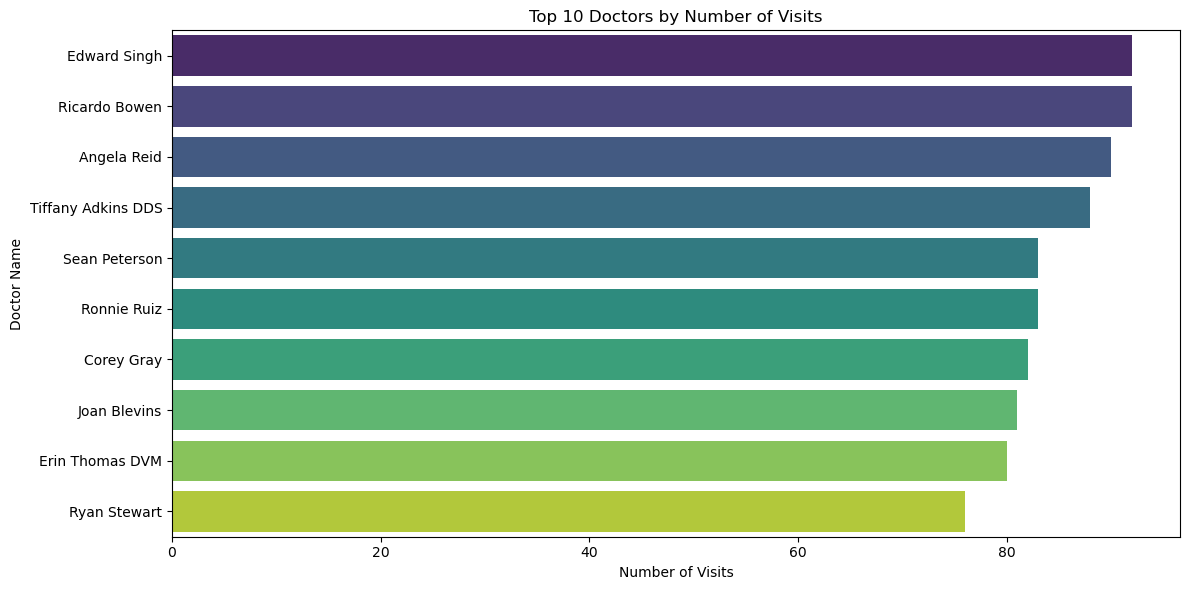

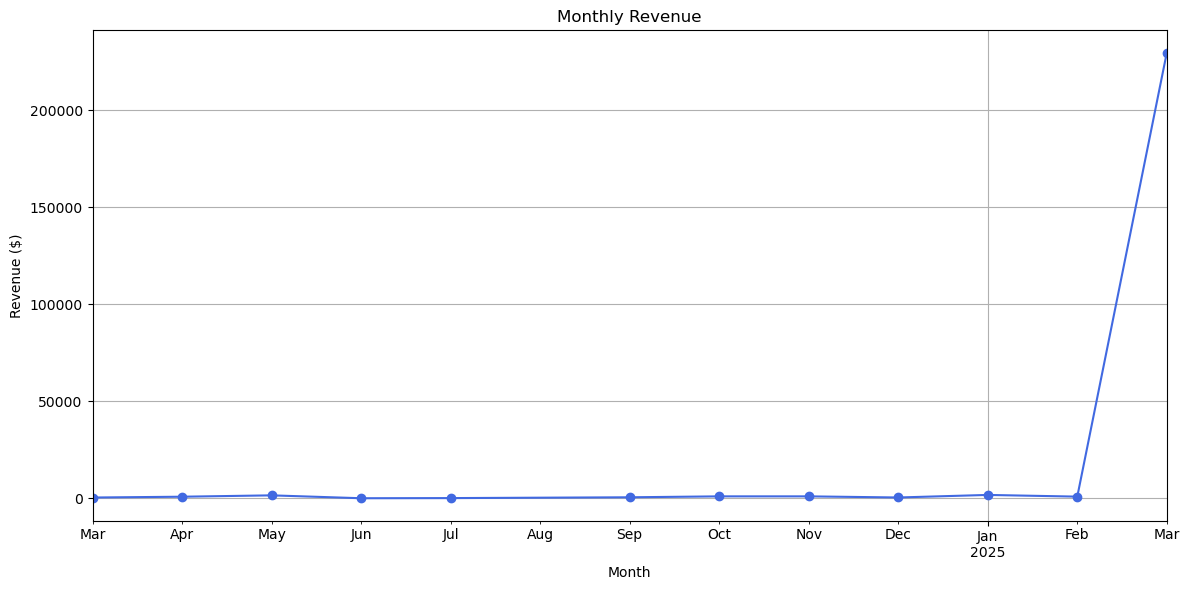

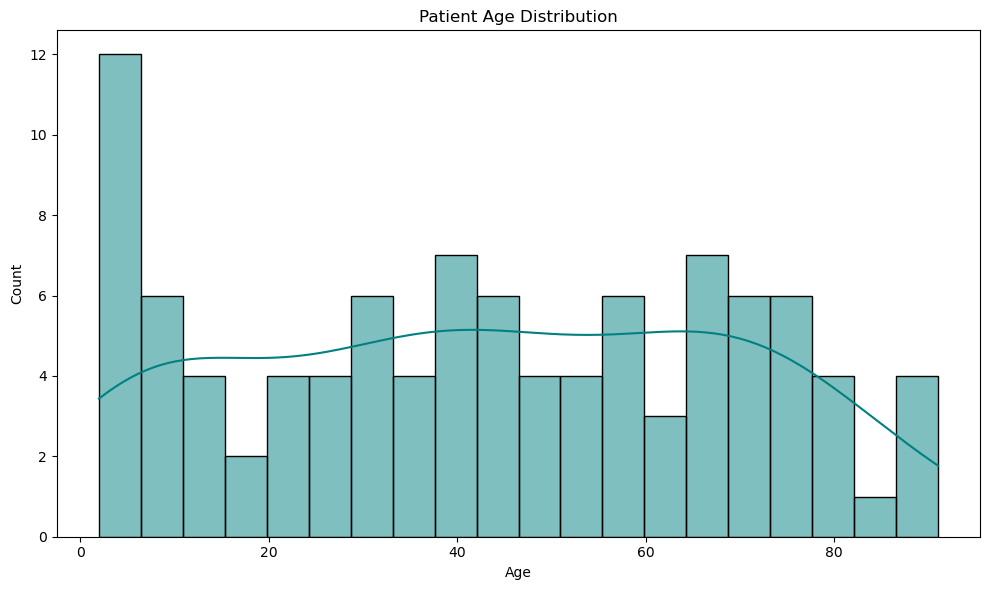

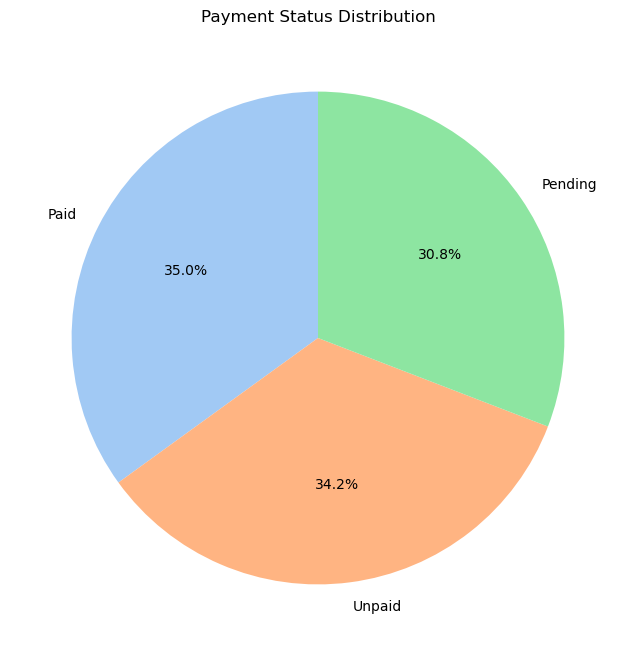

Columns in merged prescriptions data: ['doctor_id', 'dosage', 'duration', 'medicine_id', 'patient_id', 'prescription_id', 'category', 'manufacturer', 'medicine_name', 'price']


/tmp/ipykernel_147954/841037212.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_meds.values, y=top_meds.index, palette='rocket')


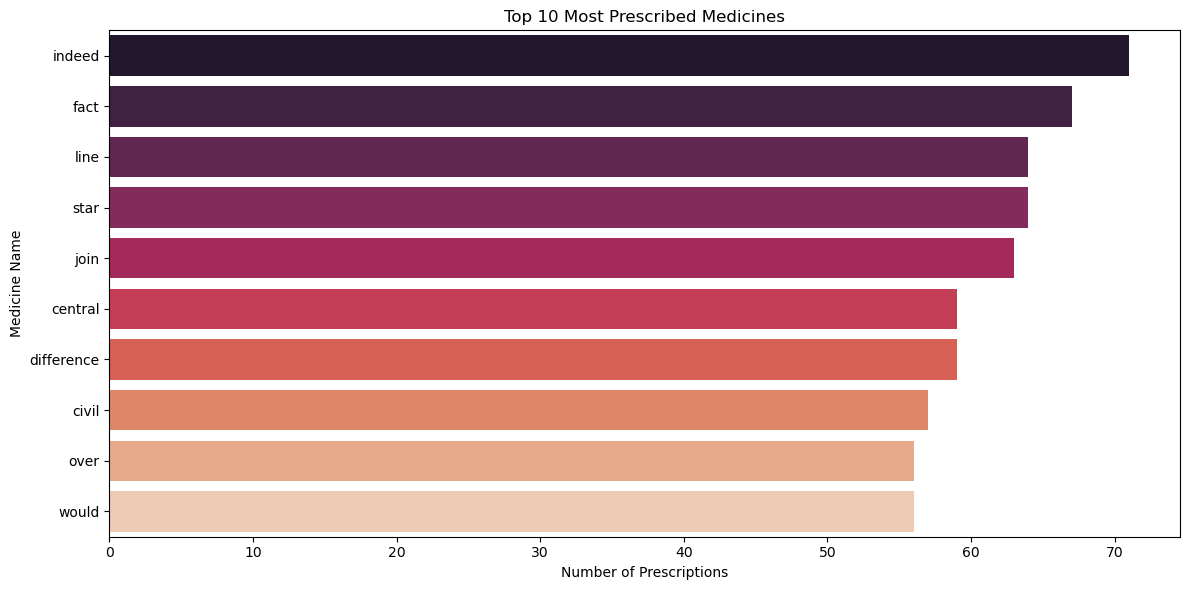

/tmp/ipykernel_147954/841037212.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=specialization_counts.values, y=specialization_counts.index, palette='mako')


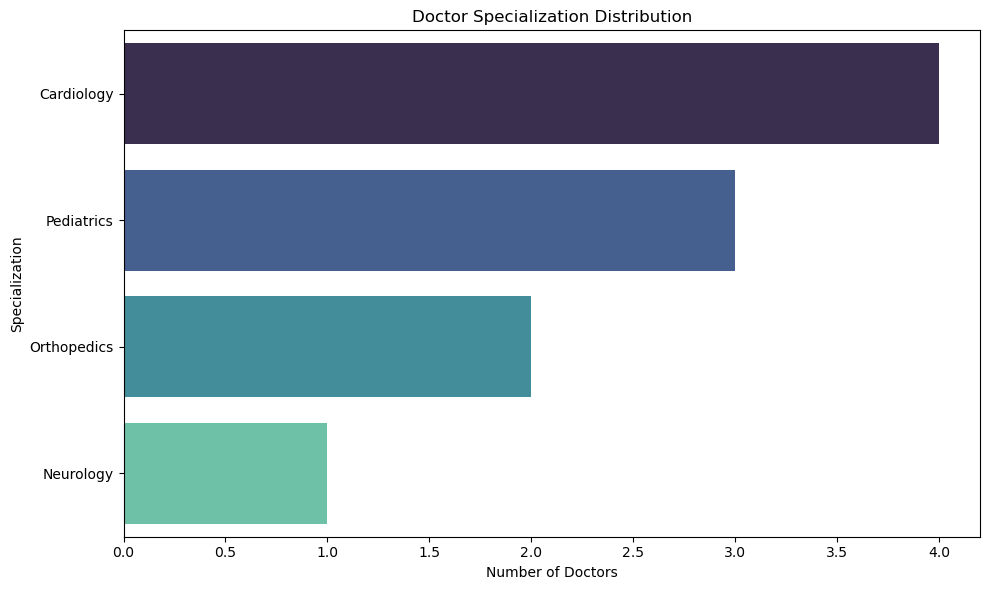

In [1]:
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datetime import datetime
import os

# Initialize Spark session with GCS configuration
spark = SparkSession.builder \
    .appName("GCSDataAnalysis") \
    .config("spark.jars", "/home/dataeng/jars/gcs-connector-hadoop3-latest.jar") \
    .config("spark.hadoop.fs.gs.impl", "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem") \
    .config("spark.hadoop.fs.AbstractFileSystem.gs.impl", "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFS") \
    .config("spark.hadoop.google.cloud.auth.service.account.enable", "true") \
    .config("spark.hadoop.google.cloud.auth.service.account.json.keyfile", "/home/dataeng/projects/dez-2025/hospital/gcs.json") \
    .getOrCreate()

# GCS bucket configuration
GCS_BUCKET = "hospital_datalake"
TABLES = ["doctors", "patients", "medicines", "visits", "billing_payments", "prescriptions"]

# Read all tables from GCS and cache them
dfs = {}
for table in TABLES:
    gcs_path = f"gs://{GCS_BUCKET}/postgres/{table}/"
    print(f"Reading {table} from {gcs_path}")
    dfs[table] = spark.read.json(gcs_path).cache()

# Convert relevant Spark DataFrames to Pandas for visualization
doctors_pd = dfs["doctors"].toPandas()
patients_pd = dfs["patients"].toPandas()
visits_pd = dfs["visits"].toPandas()
billing_pd = dfs["billing_payments"].toPandas()
prescriptions_pd = dfs["prescriptions"].toPandas()
medicines_pd = dfs["medicines"].toPandas()

# Data preprocessing
# Convert date columns to datetime
visits_pd['visit_date'] = pd.to_datetime(visits_pd['visit_date'])
billing_pd['billing_date'] = pd.to_datetime(billing_pd['billing_date'])

# Merge data for analysis
visits_with_doctors = visits_pd.merge(
    doctors_pd, 
    left_on='doctor_id', 
    right_on='doctor_id', 
    how='left'
)

billing_with_visits = billing_pd.merge(
    visits_pd, 
    left_on='visit_id', 
    right_on='visit_id', 
    how='left'
)

# Visualization 1: Doctor Performance (Number of Visits per Doctor)
plt.figure(figsize=(12, 6))
doctor_visits = visits_with_doctors['name'].value_counts().head(10)
sns.barplot(x=doctor_visits.values, y=doctor_visits.index, palette='viridis')
plt.title('Top 10 Doctors by Number of Visits')
plt.xlabel('Number of Visits')
plt.ylabel('Doctor Name')
plt.tight_layout()
plt.savefig('doctor_performance.png')
plt.show()

# Visualization 2: Monthly Revenue (using billing_date instead of payment_date)
plt.figure(figsize=(12, 6))
billing_with_visits['month'] = billing_with_visits['billing_date'].dt.to_period('M')
monthly_revenue = billing_with_visits.groupby('month')['total_amount'].sum()
monthly_revenue.plot(kind='line', marker='o', color='royalblue')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.grid(True)
plt.tight_layout()
plt.savefig('monthly_revenue.png')
plt.show()

# Visualization 3: Patient Age Distribution
plt.figure(figsize=(10, 6))
patients_pd['age'] = (pd.to_datetime('today') - pd.to_datetime(patients_pd['date_of_birth'])).dt.days // 365
sns.histplot(patients_pd['age'], bins=20, kde=True, color='teal')
plt.title('Patient Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('patient_age_distribution.png')
plt.show()

# Visualization 4: Payment Status Distribution
plt.figure(figsize=(8, 8))
payment_status = billing_pd['payment_status'].value_counts()
plt.pie(payment_status, labels=payment_status.index, autopct='%1.1f%%', 
        colors=sns.color_palette('pastel'), startangle=90)
plt.title('Payment Status Distribution')
plt.savefig('payment_status.png')
plt.show()

# Visualization 5: Prescription Medicine Analysis
prescriptions_with_meds = prescriptions_pd.merge(
    medicines_pd.rename(columns={'name': 'medicine_name'}),  # Rename before merge to avoid confusion
    left_on='medicine_id', 
    right_on='medicine_id', 
    how='left'
)

# Check available columns to debug
print("Columns in merged prescriptions data:", prescriptions_with_meds.columns.tolist())

# Find the medicine name column (it might be 'medicine_name' now)
medicine_name_col = 'medicine_name' if 'medicine_name' in prescriptions_with_meds.columns else 'name'

top_meds = prescriptions_with_meds[medicine_name_col].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_meds.values, y=top_meds.index, palette='rocket')
plt.title('Top 10 Most Prescribed Medicines')
plt.xlabel('Number of Prescriptions')
plt.ylabel('Medicine Name')
plt.tight_layout()
plt.savefig('top_medicines.png')
plt.show()

# Visualization 6: Doctor Specialization Distribution
plt.figure(figsize=(10, 6))
specialization_counts = doctors_pd['specialization'].value_counts()
sns.barplot(x=specialization_counts.values, y=specialization_counts.index, palette='mako')
plt.title('Doctor Specialization Distribution')
plt.xlabel('Number of Doctors')
plt.ylabel('Specialization')
plt.tight_layout()
plt.savefig('doctor_specializations.png')
plt.show()

# Visualization 7: Visit Diagnosis Word Cloud (optional)
# Uncomment if you want to generate a word cloud of common diagnoses
"""
from wordcloud import WordCloud

diagnosis_text = ' '.join(visits_pd['diagnosis'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(diagnosis_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Common Diagnosis Terms')
plt.savefig('diagnosis_wordcloud.png')
plt.show()
"""

# Close Spark session
spark.stop()